In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [4]:
def my_ft(k_values, r_s, rvir):
    fourier_transform = np.zeros_like(k_values)
    
    c = rvir/r_s
    print(c)
    for i, k in enumerate(k_values):
        kr_s = k * r_s
        Si_c, Ci_c = sici((1+c)*kr_s)
        Si, Ci = sici(kr_s)
        f = 1/(np.log(1+c) - c/(1+c))
        term1 = np.sin(kr_s) * (Si_c - Si)
        term2 = np.cos(kr_s) * (Ci_c - Ci)
        term3 = -np.sin(c*kr_s)/((1+c)*kr_s)
        fourier_transform[i] = f*(term1 + term2 + term3)
    
    return fourier_transform

In [5]:
def my_uk2(k_values, r_s, rvir):
    return my_ft(k_values, r_s, rvir)**2

In [12]:
def pkpc_h_to_cmpc_h(z):
    return (1+z)/1e3

In [13]:
z0=1.5

In [17]:
logks_test = np.arange(-1.5,1.5, 0.1)
ks_test = 10**logks_test

In [40]:
rho0_pkpc_h = 6733038.060385219
rs_pkpc_h = 24.44172432883047
rs_pkpc_h = 70.2107983709715
#r_vals_cmpc_h = r_vals_pkpc_h * pkpc_h_to_cmpc_h(z0)
z0=1.5
rs_0 = rs_pkpc_h * pkpc_h_to_cmpc_h(z0)
rho_0 = rho0_pkpc_h / (pkpc_h_to_cmpc_h(z0)**3)
rvir = 0.5

print(rs_0)
print(rvir)
nfw_ft = my_ft(ks_test, rs_0, rvir)

0.17552699592742876
0.5
2.848564674386177


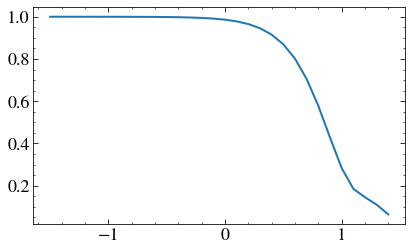

In [19]:
plt.plot(logks_test, nfw_ft)

### TNG

In [20]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [21]:
odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [116]:
logMmin = 11.0
logMmax = 11.1

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk11_sum = pickle.load(f)
print("shotnoise", Pk11_sum.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk11_gal = pickle.load(f)
print("shotnoise", Pk11_gal.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/sat/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk11_sat = pickle.load(f)
print("shotnoise", Pk11_sat.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/sat_sum/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk11_sat_sum = pickle.load(f)
print("shotnoise", Pk11_sat_sum.attrs["shotnoise"])



shotnoise 286.3949289238728
shotnoise 262.72067788705453
shotnoise 1291.2422729079112
shotnoise 7121.333020765635


FileNotFoundError: [Errno 2] No such file or directory: '../ps_data/snap40/mvir/number_density/gal/logM_range/logM11.0-11.1.pickle'

In [26]:
logMmin = 12.0
logMmax = 12.5

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk12_sum = pickle.load(f)
print("shotnoise", Pk12_sum.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk12_gal = pickle.load(f)
print("shotnoise", Pk12_gal.attrs["shotnoise"])

shotnoise 926.3583221039135
shotnoise 570.3881129171369


In [189]:
logMmin = 13.0
logMmax = 13.5

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum = pickle.load(f)
print("shotnoise", Pk13_sum.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal = pickle.load(f)
print("shotnoise", Pk13_gal.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/sat/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sat = pickle.load(f)
print("shotnoise", Pk13_sat.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/sat_sum/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sat_sum = pickle.load(f)
print("shotnoise", Pk13_sat_sum.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/number_density/group/logM_range/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum_n = pickle.load(f)
print("shotnoise", Pk13_sum_n.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/number_density/gal/logM_range/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal_n = pickle.load(f)
print("shotnoise", Pk13_gal_n.attrs["shotnoise"])


odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/number_density/sat_sum/logM_range/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sat_sum_n = pickle.load(f)
print("shotnoise", Pk13_sat_sum_n.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/number_density/sat/logM_range/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sat_n = pickle.load(f)
print("shotnoise", Pk13_sat_n.attrs["shotnoise"])


shotnoise 18362.083969661016
shotnoise 3598.289449321791
shotnoise 3931.5569440373647
shotnoise 18943.2616934025
shotnoise 14317.727258428895
shotnoise 460.70187165775405
shotnoise 11769.29644808743
shotnoise 479.4704474621549


In [186]:
Pk13_gal["power"].real

array([70156.57211538, 44074.36842105, 35735.55454545, 31620.44173442,
       24513.32068966, 23235.44539615, 22332.0941968 , 20763.69395466,
       20078.31939163, 18833.34211546, 19374.4562982 , 18796.6664895 ,
       17901.44131028, 18706.39748625, 17770.00501924, 18123.3145933 ,
       17896.8940678 , 17625.38826001, 17656.82335887, 17398.03394381,
       17279.23636364, 17083.67939413, 16833.89149706, 16963.20228216,
       16636.4240743 , 16543.61450064, 16533.76379921, 16056.02282671,
       15868.42021019, 16067.91950773, 15574.52850147, 15694.18189724,
       15474.02894555, 15479.35563688, 15310.06057669, 15169.77325783,
       14906.72064689, 14893.66000723, 14893.61580455, 14745.71715295,
       14516.96409893, 14510.30383102, 14380.89917514, 14262.97572703,
       14375.90059111, 14266.91128072, 14079.52372093, 14060.01176922,
       13884.2522165 , 13835.64153712, 13733.75394898, 13625.674378  ,
       13568.11154979, 13486.35139137, 13363.65003445, 13237.42788683,
      

shotnoise:  460.70187165775405
shotnoise:  11769.29644808743


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1487: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


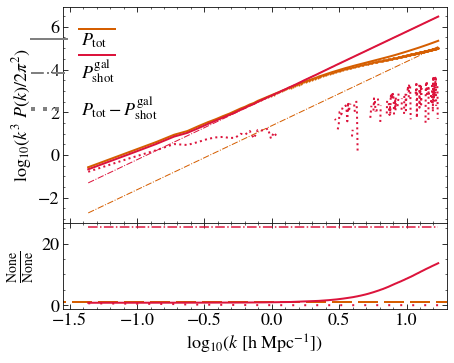

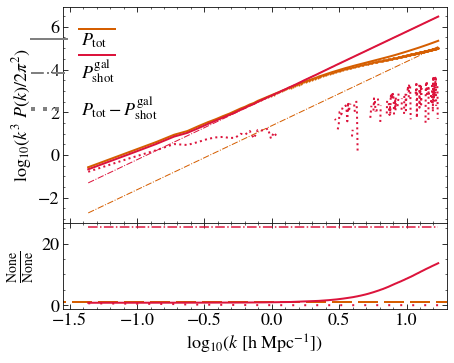

In [119]:
ps.compare_ps_plot([Pk13_gal_n, Pk13_sum_n], shotnoise_subtracted_ps=True)

In [123]:
ks_tng = Pk_gal10["k"]

kcoef_tng = ks_tng**3 / (2 * np.pi **2)
tot = (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"]))

In [124]:
shot_gal = Pk_gal10.attrs["shotnoise"]
shot_halo = Pk_sum10.attrs["shotnoise"]

In [125]:
uk = (tot - shot_gal)/(shot_halo - shot_gal)

In [33]:
def compute_uk2(Pk_gal10, Pk_sum10):
    ks_tng = Pk_gal10["k"]


    tot = (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"]))
    
    shot_gal = Pk_gal10.attrs["shotnoise"]
    shot_halo = Pk_sum10.attrs["shotnoise"]
    uk2 = (tot - shot_gal)/(shot_halo - shot_gal)
    return uk2

In [70]:
uk2_13 = compute_uk2(Pk13_gal, Pk13_sum)
uk2_12 = compute_uk2(Pk12_gal, Pk12_sum)
uk2_11 = compute_uk2(Pk11_gal, Pk11_sum)

In [191]:
uk2_11_sat = compute_uk2(Pk11_sat, Pk11_sat_sum)
uk2_13_sat = compute_uk2(Pk13_sat, Pk13_sat_sum)

In [159]:
uk2_13_n = compute_uk2(Pk13_gal_n, Pk13_sum_n)

In [171]:
uk2_13_n_sat = compute_uk2(Pk13_sat_n, Pk13_sat_sum_n)

In [71]:
uk2_all = compute_uk2(Pk_gal10, Pk_sum10)

In [72]:
rs_0 = 0.176
rvir = 0.3
nfw_ft = my_ft(ks_test, rs_0, rvir)

1.7045454545454546


1.0
2500.0


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


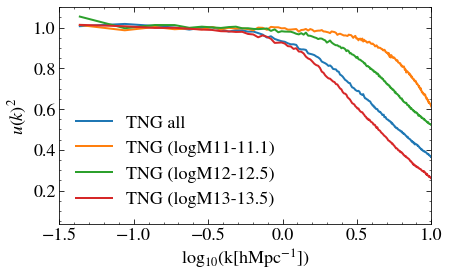

In [299]:
plt.plot(np.log10(ks_tng), uk2_all, label="TNG all")
plt.plot(np.log10(ks_tng), uk2_11, label="TNG (logM11-11.1)")
#plt.plot(np.log10(ks_tng), uk2_13_n, label="TNG (logM13-13.5, number)")
#plt.plot(np.log10(ks_tng), uk2_13_n_sat, label="TNG (logM13-13.5, number,sat)")

plt.plot(np.log10(ks_tng), uk2_12, label="TNG (logM12-12.5)")
plt.plot(np.log10(ks_tng), uk2_13, label="TNG (logM13-13.5)")
#plt.plot(np.log10(ks_tng), uk2_13_sat, label="TNG (logM13-13.5), sat")

rvir = 0.5
rs_0 = 0.5
nfw_ft = my_uk2(ks_test, rs_0, rvir)
#plt.plot(logks_test, nfw_ft, label=f"$r_s={rs_0},r_{{vir}}={rvir}$")

rvir = 0.5
rs_0 = 0.0002
nfw_ft = my_uk2(ks_test, rs_0, rvir)
#plt.plot(logks_test, nfw_ft, label=f"$r_s={rs_0},r_{{vir}}={rvir}$")

#plt.plot(logks, ftc5, label="c=5")
#plt.plot(logks, ftc4, label="c=4")
#plt.plot(logks, ftc5, label=f"NFW, logM11 (c=5, Rmax=118)")
#plt.plot(logks, ft12, label=f"NFW, logM12 (c=4, Rmax=250)")
#plt.plot(logks_tng, uk1, label=f"NFW, logM12 (c=5, Rmax=500)")
#plt.plot(logks_tng, uk2, label=f"NFW, logM12 (c=5, Rmax=500)")

#plt.plot(logks, ft13, label=f"NFW, logM13 (c=3.5, Rmax=550)")
plt.ylabel("$u(k)^2$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc^{-1}])$")
plt.xlim(-1.5,1.5)
#plt.ylim(0,1)
plt.legend()

In [1]:
plt.plot(np.log10(ks_tng), uk2_all, label="TNG all")
plt.plot(np.log10(ks_tng), uk2_11, label="TNG (logM11-11.1)")
#plt.plot(np.log10(ks_tng), uk2_13_n, label="TNG (logM13-13.5, number)")
#plt.plot(np.log10(ks_tng), uk2_13_n_sat, label="TNG (logM13-13.5, number,sat)")

plt.plot(np.log10(ks_tng), uk2_12, label="TNG (logM12-12.5)")
plt.plot(np.log10(ks_tng), uk2_13, label="TNG (logM13-13.5)")
#plt.plot(np.log10(ks_tng), uk2_13_sat, label="TNG (logM13-13.5), sat")

rvir = 0.5
rs_0 = 0.5
nfw_ft = my_uk2(ks_test, rs_0, rvir)
#plt.plot(logks_test, nfw_ft, label=f"$r_s={rs_0},r_{{vir}}={rvir}$")

rvir = 0.5
rs_0 = 0.0002
nfw_ft = my_uk2(ks_test, rs_0, rvir)
#plt.plot(logks_test, nfw_ft, label=f"$r_s={rs_0},r_{{vir}}={rvir}$")

#plt.plot(logks, ftc5, label="c=5")
#plt.plot(logks, ftc4, label="c=4")
#plt.plot(logks, ftc5, label=f"NFW, logM11 (c=5, Rmax=118)")
#plt.plot(logks, ft12, label=f"NFW, logM12 (c=4, Rmax=250)")
#plt.plot(logks_tng, uk1, label=f"NFW, logM12 (c=5, Rmax=500)")
#plt.plot(logks_tng, uk2, label=f"NFW, logM12 (c=5, Rmax=500)")

#plt.plot(logks, ft13, label=f"NFW, logM13 (c=3.5, Rmax=550)")
plt.ylabel("$u(k)^2$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc^{-1}])$")
plt.xlim(-1.5,1.5)
#plt.ylim(0,1)
plt.legend()

NameError: name 'plt' is not defined

In [290]:
from colossus.cosmology import cosmology
from colossus.halo import profile_nfw

cosmo = cosmology.setCosmology('planck15')
p_nfw = profile_nfw.NFWProfile(M = 1E13, c = 1
                               , z = z0, mdef = 'vir')

In [277]:
rs_ckpc = 10
rho0_pkpc = 1
rs_pkpc = rs_ckpc/(1+z0)
p_nfw = profile_nfw.NFWProfile(rhos=rho0_pkpc, rs=rs_pkpc)

In [291]:
Rmax_ckpc = 500
r1 = np.linspace(1e-3, Rmax_ckpc*(1+z0), 10000)
rho_nfw = p_nfw.density(r1)

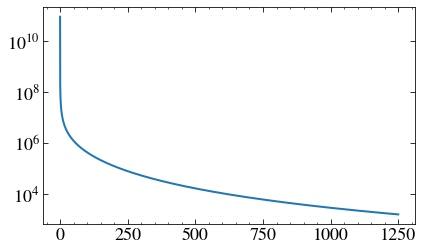

In [292]:
plt.plot(r1, rho_nfw)
plt.yscale("log")